In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.gridspec import GridSpec
import matplotlib.animation as animation
import ffmpeg
from IPython.display import HTML
#import everything required

In [2]:
#the 4 neighbors, up down left right
def neumann_offset(x, y, o):
    neighbors = []
    for di in range(-o, o + 1):
        for dj in range(-o, o + 1):
            if (di != 0 or dj != 0) and abs(di) + abs(dj) <= o:
                neighbors.append((x + di, y + dj))
    return neighbors

#8 neighbors including diagonals
def moore_offset(x, y, o):
    neighbors = []
    for di in range(-o, o + 1):
        for dj in range(-o, o + 1):
            if (di, dj) != (0, 0):
                neighbors.append((x + di, y + dj))
    return neighbors


# states: 0 = Susceptible, 1 = Exposed, 2 = Infected, 3 = Recovered
def state_transition(M, R_clock, state, X, offset, L, sigma, gamma, tau, beta, delta, t):
    if state == 0:  # Susceptible
        PBC_N = (offset + X) % L #it accounts for the boundary conditions
        for j in PBC_N:
            N_state = M[j[0], j[1]]
            if N_state == 2:  # found an infected neighbour
                if np.random.random() < beta:
                    M[X[0], X[1]] = 1  # S -> E
                return

    if state == 1:  # Exposed
        if np.random.random() < sigma:
            M[X[0], X[1]] = 2  # E -> I
            return

    if state == 2:  # Infected
        if np.random.random() < gamma:
            M[X[0], X[1]] = 3  # I -> R
            #Rclock introduced as a timekeeping matrix
            R_clock[X[0], X[1]] = t
            return

    if state == 3:  # Recovered
        if t - R_clock[X[0], X[1]] >= tau:  # immunity period has elapsed, where the Rclock time is more than tau
            if np.random.random() < delta:  #and now delta is the probability to go from R to S
                M[X[0], X[1]] = 0  # R -> S
            return




In [3]:
#defining the initial lattice - the function for it
def initial_condition(S_F, E_F, I_F, R_F, L):
    return np.random.choice([0, 1, 2, 3], p=[S_F, E_F, I_F, R_F], size=(L, L))


offset1 = np.array(moore_offset(0, 0, 2), dtype=int)
offset2 = np.array(neumann_offset(0, 0, 1), dtype=int)

L = int(100)
np.random.seed(0)
#finally defining the initial lattice M
M = initial_condition(0.99, 0.01, 0.00, 0.00, L)
#defining R_clock - which holds np.zeros
R_clock = np.zeros((L, L), dtype=int)
#defining all the values
sigma = 0.9
gamma = 0.3
beta = 0.95
tau = 150000 #time delay value
delta = 1.0  # R -> S once tau is over

n_iter = 1000000

#timestamps for lattice snapshots
snapshot_times = [30000, 150000, 240000, 350000, 460000, 580000, 670000, 780000]
snapshots = {}

S, E, I, R, T, history= [], [], [], [], [], []
history.append(M.copy())
snap_set = set(snapshot_times)
for i in range(n_iter):
    X = np.random.randint(0, L, size=(2), dtype=int)
    X_state = M[X[0], X[1]]

    state_transition(M, R_clock, X_state, X, offset1, L, sigma, gamma, tau, beta, delta, i)

    if i in snap_set:
        snapshots[i] = M.copy()

    if i % 500 == 1:
        S.append(np.sum(M == 0))
        E.append(np.sum(M == 1))
        I.append(np.sum(M == 2))
        R.append(np.sum(M == 3))
        T.append(i)
    if i % 5000 == 1:
        history.append(M.copy())


S = np.array(S) / L / L
E = np.array(E) / L / L
I = np.array(I) / L / L
R = np.array(R) / L / L



saved


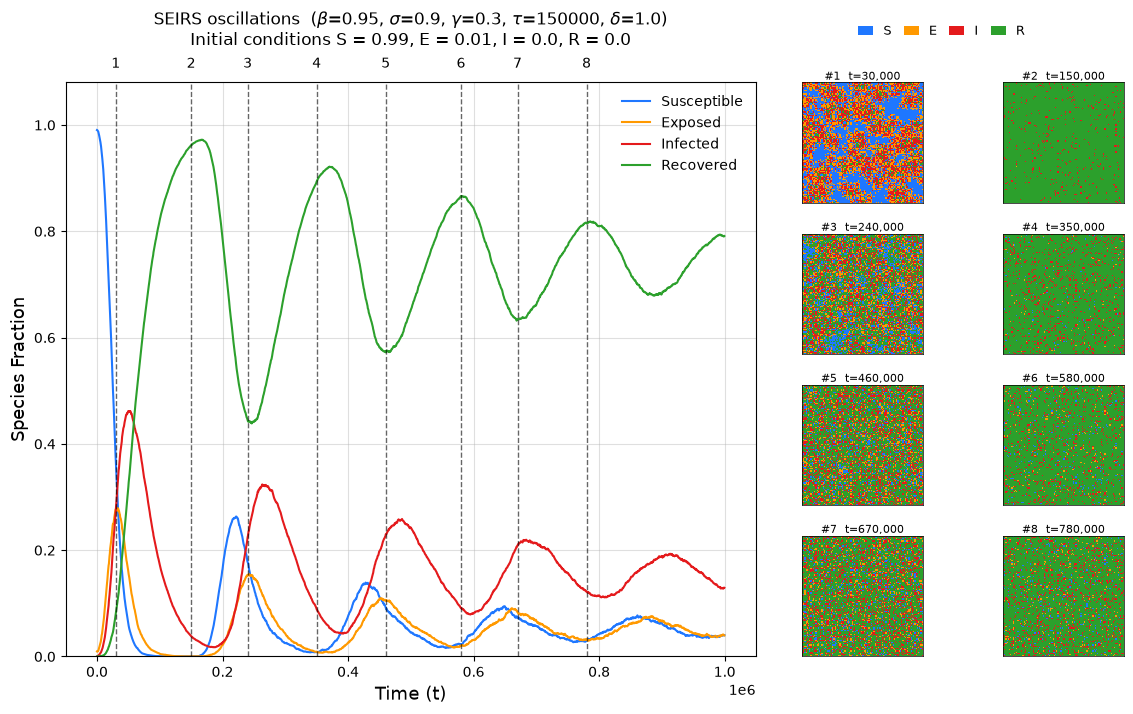

In [4]:
#side-by-side figure: graph curve + lattice snapshots (right)
plt.style.use('default')
cmap = ListedColormap(["#1f77ff", "#ff9900", "#e41a1c", "#2ca02c"])  # S, E, I, R
#plot the final figure
fig = plt.figure(figsize=(12, 7))
gs = GridSpec(4, 5, figure=fig, wspace=0.06, hspace=0.25,
              left=0.07, right=0.98, top=0.90, bottom=0.08,
              width_ratios=[1, 1, 1, 0.85, 0.85])

# the graph on the left
ax0 = fig.add_subplot(gs[:, 0:3])
ax0.plot(T, S, label="Susceptible", color="#1f77ff")
ax0.plot(T, E, label="Exposed", color="#ff9900")
ax0.plot(T, I, label="Infected", color="#e41a1c")
ax0.plot(T, R, label="Recovered", color="#2ca02c")
#mark all the snapshot times with a dashed line
for k, ts in enumerate(snapshot_times):
    ax0.axvline(ts, color="k", linestyle="--", linewidth=1, alpha=0.6)
    ax0.text(ts, 1.02, str(k + 1), ha="center", va="bottom", fontsize=10,
             transform=ax0.get_xaxis_transform())
ax0.set_xlabel("Time (t)", fontsize=13)
ax0.set_ylabel("Species Fraction", fontsize=13)
ax0.set_title(
    rf"""SEIRS oscillations  ($\beta$={beta}, $\sigma$={sigma}, $\gamma$={gamma}, $\tau$={tau}, $\delta$={delta})
Initial conditions S = 0.99, E = 0.01, I = 0.0, R = 0.0""",
    fontsize=12, pad=27)
ax0.legend(frameon=False, loc="upper right", fontsize=10)
ax0.set_ylim(0, 1.08)
ax0.grid(alpha = 0.4)

# right: 4x2 grid of lattice snapshots, tightly packed in the last 2 columns
positions = [(0, 3), (0, 4), (1, 3), (1, 4), (2, 3), (2, 4), (3, 3), (3, 4)]
for k, ts in enumerate(snapshot_times):
    r, c = positions[k]
    ax = fig.add_subplot(gs[r, c])
    ax.imshow(snapshots[ts], cmap=cmap, vmin=0, vmax=3, interpolation="nearest")
    ax.set_title(f"#{k + 1}  t={ts:,}", fontsize=8, pad=2)
    ax.set_xticks([]);
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.5)

# shared legend for lattice colors
from matplotlib.patches import Patch

legend_elems = [Patch(facecolor="#1f77ff", label="S"),
                Patch(facecolor="#ff9900", label="E"),
                Patch(facecolor="#e41a1c", label="I"),
                Patch(facecolor="#2ca02c", label="R")]
fig.legend(handles=legend_elems, loc="upper center", ncol=4, frameon=False,
           bbox_to_anchor=(0.8, 1.0), fontsize=9, handlelength=1.2, columnspacing=1.0)

plt.savefig("seirs_lattice_side_by_side.png", dpi=160, bbox_inches="tight")
print("saved")

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.style.use('default')

cmap = ListedColormap(['#003c91', '#f5a623', '#f5272e', '#066b29'])

im = ax.imshow(history[0], cmap=cmap, vmin=0, vmax=3)
ax.axis('off')
title = ax.set_title("SEIRS Simulation - Frame 0")

def update(frame_idx):
    im.set_array(history[frame_idx])
    title.set_text(f"SEIRS Simulation - Frame {frame_idx}")
    return [im, title]

ani = animation.FuncAnimation(
    fig, update, frames=len(history), interval=50, blit=True
)
ani.save("seirs - oscillation stochastic.mp4", writer="ffmpeg", fps=30)

HTML(ani.to_jshtml())